In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
True
12.1
NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
pip install gseapy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import requests
from tqdm import tqdm
import time
import gseapy as gp

In [4]:
ADHD_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\ADHD2022\ADHD2022_iPSYCH_deCODE_PGC\ADHD2022.tsv"  
ASD_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\14671989\iPSYCH-PGC_ASD_Nov2017\ASD2019.tsv"
Dyslexia_file_path = r"C:\Users\tharu\Desktop\Starlight\FYP\Cross-Disorder_Multi-Label_Classification_Using_Transformer_and_Graph-Based_Fusion_for_Dyslexia_ADHD_and_Autism\Datasets\Genomic Data\Dyslexia_GWAS_Summary_Statistics_for_top_10K_SNPs\top_10K_variants.txt"

In [5]:
ADHD_df = pd.read_csv(
    ADHD_file_path,
    delim_whitespace=True,
    low_memory=False
)

ASD_df = pd.read_csv(
    ASD_file_path,
    delim_whitespace=True,
    low_memory=False
)

dys_df = pd.read_csv(
    Dyslexia_file_path, 
    sep="\t", 
    low_memory=False)

C:\Users\tharu\AppData\Local\Temp\ipykernel_47380\1698581988.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ADHD_df = pd.read_csv(
C:\Users\tharu\AppData\Local\Temp\ipykernel_47380\1698581988.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ASD_df = pd.read_csv(


In [6]:
ADHD_df.head()

,CHR,SNP,BP,A1,A2,FRQ_A_38691,FRQ_U_186843,INFO,OR,SE,P,Direction,Nca,Nco
0,8,rs62513865,101592213,C,T,0.925,0.937,0.981,0.99631,0.0175,0.8325,+---+++0-++-+,38691,186843
1,8,rs79643588,106973048,G,A,0.910,0.917,1.000,1.00411,0.0159,0.7967,++--++-+-+-++,38691,186843
2,8,rs17396518,108690829,T,G,0.561,0.577,0.998,0.99611,0.0096,0.6876,--++-++??-+--,37367,184388
3,8,rs983166,108681675,A,C,0.570,0.586,0.996,0.99491,0.0096,0.5956,--++-++++-+--,38691,186843
4,8,rs28842593,103044620,T,C,0.839,0.836,0.982,0.98314,0.0135,0.2081,----++0+??--+,37504,184525


In [7]:
ASD_df.head()

,CHR,SNP,BP,A1,A2,INFO,OR,SE,P
0,8,rs62513865,101592213,T,C,0.949,1.00652,0.0270,0.808600
1,8,rs79643588,106973048,A,G,0.997,1.01786,0.0240,0.460600
2,8,rs17396518,108690829,T,G,0.987,0.96127,0.0140,0.004647
3,8,rs983166,108681675,A,C,0.998,0.97990,0.0139,0.145200
4,8,rs28842593,103044620,T,C,0.857,0.99591,0.0203,0.841500


In [8]:
dys_df.head()

,assay.name,scaffold,position,effect_allele,other_allele,effect,stderr,pvalue,avg.rsqr
0,rs13082684,chr3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,chr3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,chr3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,chr3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,chr3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492


In [9]:
n = 5  # number of values to inspect per column

for col in ADHD_df.columns:
    print(f"\nColumn: {col}")
    print(ADHD_df[col].head(n).to_list())



Column: CHR
[8, 8, 8, 8, 8]

Column: SNP
['rs62513865', 'rs79643588', 'rs17396518', 'rs983166', 'rs28842593']

Column: BP
[101592213, 106973048, 108690829, 108681675, 103044620]

Column: A1
['C', 'G', 'T', 'A', 'T']

Column: A2
['T', 'A', 'G', 'C', 'C']

Column: FRQ_A_38691
[0.925, 0.91, 0.561, 0.57, 0.839]

Column: FRQ_U_186843
[0.937, 0.917, 0.577, 0.586, 0.836]

Column: INFO
[0.981, 1.0, 0.998, 0.996, 0.982]

Column: OR
[0.99631, 1.00411, 0.99611, 0.99491, 0.98314]

Column: SE
[0.0175, 0.0159, 0.0096, 0.0096, 0.0135]

Column: P
[0.8325, 0.7967, 0.6876, 0.5956, 0.2081]

Column: Direction
['+---+++0-++-+', '++--++-+-+-++', '--++-++??-+--', '--++-++++-+--', '----++0+??--+']

Column: Nca
[38691, 38691, 37367, 38691, 37504]

Column: Nco
[186843, 186843, 184388, 186843, 184525]


In [10]:
n = 5  # number of values to inspect per column

for col in ASD_df.columns:
    print(f"\nColumn: {col}")
    print(ADHD_df[col].head(n).to_list())



Column: CHR
[8, 8, 8, 8, 8]

Column: SNP
['rs62513865', 'rs79643588', 'rs17396518', 'rs983166', 'rs28842593']

Column: BP
[101592213, 106973048, 108690829, 108681675, 103044620]

Column: A1
['C', 'G', 'T', 'A', 'T']

Column: A2
['T', 'A', 'G', 'C', 'C']

Column: INFO
[0.981, 1.0, 0.998, 0.996, 0.982]

Column: OR
[0.99631, 1.00411, 0.99611, 0.99491, 0.98314]

Column: SE
[0.0175, 0.0159, 0.0096, 0.0096, 0.0135]

Column: P
[0.8325, 0.7967, 0.6876, 0.5956, 0.2081]


In [11]:
n = 5  # number of values to inspect per column

for col in dys_df.columns:
    print(f"\nColumn: {col}")
    print(dys_df[col].head(n).to_list())



Column: assay.name
['rs13082684', 'rs7628848', 'rs10048942', 'rs28509770', 'rs28576629']

Column: scaffold
['chr3', 'chr3', 'chr3', 'chr3', 'chr3']

Column: position
[135783166, 135781940, 135785491, 135793657, 135773661]

Column: effect_allele
['G', 'G', 'G', 'G', 'T']

Column: other_allele
['A', 'A', 'A', 'C', 'G']

Column: effect
[-0.0667863617594715, -0.0666284214337651, 0.0665788559688778, 0.0657198142549327, 0.066345111895225]

Column: stderr
[0.008005134111557, 0.008000477687492, 0.0080039638069562, 0.0079368881330161, 0.0080096777390211]

Column: pvalue
[1.02885250871639e-16, 1.16380110142833e-16, 1.26316637374567e-16, 1.69038682912248e-16, 1.6915792743937099e-16]

Column: avg.rsqr
[0.989839136600494, 0.989948153495789, 0.989762485027313, 0.972897887229919, 0.989492356777191]


In [12]:
ADHD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6774224 entries, 0 to 6774223
Data columns (total 14 columns):
 #   Column        Dtype  
---  ------        -----  
 0   CHR           int64  
 1   SNP           object 
 2   BP            int64  
 3   A1            object 
 4   A2            object 
 5   FRQ_A_38691   float64
 6   FRQ_U_186843  float64
 7   INFO          float64
 8   OR            float64
 9   SE            float64
 10  P             float64
 11  Direction     object 
 12  Nca           int64  
 13  Nco           int64  
dtypes: float64(6), int64(4), object(4)
memory usage: 723.6+ MB


In [13]:
ASD_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9112386 entries, 0 to 9112385
Data columns (total 9 columns):
 #   Column  Dtype  
---  ------  -----  
 0   CHR     int64  
 1   SNP     object 
 2   BP      int64  
 3   A1      object 
 4   A2      object 
 5   INFO    float64
 6   OR      float64
 7   SE      float64
 8   P       float64
dtypes: float64(4), int64(2), object(3)
memory usage: 625.7+ MB


In [14]:
dys_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   assay.name     10000 non-null  object 
 1   scaffold       10000 non-null  object 
 2   position       10000 non-null  int64  
 3   effect_allele  10000 non-null  object 
 4   other_allele   10000 non-null  object 
 5   effect         10000 non-null  float64
 6   stderr         10000 non-null  float64
 7   pvalue         10000 non-null  float64
 8   avg.rsqr       10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.2+ KB


 | Column           | Meaning                                                |
 | ---------------- | ------------------------------------------------------ |
 | **CHR**          | Chromosome number                                      |
 | **SNP**          | rsID                                                   |
 | **BP**           | Base-pair position (hg19 / hg38                        |
 | **A1**           | Effect allele                                          |
 | **A2**           | Other allele                                           |
 | **FRQ_A_38691**  | Effect allele frequency in cases                       |
 | **FRQ_U_186843** | Effect allele frequency in controls                    |
 | **INFO**         | Imputation quality (keep ≥ 0.8)                        |
 | **OR**           | Odds ratio (logistic GWAS)                             |
 | **SE**           | Standard error                                         |
 | **P**            | P-value                                                |
 | **Direction**    | Per-cohort effect direction                            |
 | **Nca**          | Number of cases                                        |
 | **Nco**          | Number of controls                                     |


### Rename Columns to match each dataset

In [15]:
# Rename columns
ADHD_df = ADHD_df.rename(columns={
    "CHR": "CHR",
    "BP": "BP",
    "SNP": "SNP",
    "A1": "A1",
    "A2": "A2",
    "OR": "OR",
    "SE": "SE",
    "P": "P"
})

# Keep only required columns
ADHD_df = ADHD_df[["CHR", "BP", "SNP", "A1", "A2", "OR", "SE", "P"]]
ASD_df = ASD_df[["CHR", "BP", "SNP", "A1", "A2", "OR", "SE", "P"]]

In [16]:
dys_df.rename(columns={
    "assay.name": "SNP",
    "scaffold": "CHR",
    "position": "BP",
    "effect_allele": "A1",
    "other_allele": "A2",
    "effect": "BETA",
    "stderr": "SE",
    "pvalue": "P",
    "avg.rsqr": "INFO"
}, inplace=True)

def chr_to_int(chr_val):
    chr_val = str(chr_val).replace("chr", "")  # remove "chr" prefix
    if chr_val.isdigit():
        return int(chr_val)
    elif chr_val.upper() == "X":
        return 23
    elif chr_val.upper() == "Y":
        return 24
    else:
        return np.nan  # for MT or unknown

dys_df["CHR"] = dys_df["CHR"].apply(chr_to_int)
dys_df = dys_df.dropna(subset=["CHR"])  # drop non-autosomes/unknown chromosomes
dys_df["CHR"] = dys_df["CHR"].astype(int)


In [17]:
ADHD_df

,CHR,BP,SNP,A1,A2,OR,SE,P
0,8,101592213,rs62513865,C,T,0.99631,0.0175,0.8325
1,8,106973048,rs79643588,G,A,1.00411,0.0159,0.7967
2,8,108690829,rs17396518,T,G,0.99611,0.0096,0.6876
3,8,108681675,rs983166,A,C,0.99491,0.0096,0.5956
4,8,103044620,rs28842593,T,C,0.98314,0.0135,0.2081
...,...,...,...,...,...,...,...,...
6774219,20,44372620,rs2425746,T,C,1.01369,0.0096,0.1555
6774220,20,49004040,rs6067431,C,T,0.99442,0.0099,0.5696
6774221,20,40403831,rs1475049,G,A,0.96262,0.0300,0.2043
6774222,20,46761380,rs117705259,G,A,1.03490,0.0468,0.4637


In [18]:
ASD_df

,CHR,BP,SNP,A1,A2,OR,SE,P
0,8,101592213,rs62513865,T,C,1.00652,0.0270,0.808600
1,8,106973048,rs79643588,A,G,1.01786,0.0240,0.460600
2,8,108690829,rs17396518,T,G,0.96127,0.0140,0.004647
3,8,108681675,rs983166,A,C,0.97990,0.0139,0.145200
4,8,103044620,rs28842593,T,C,0.99591,0.0203,0.841500
...,...,...,...,...,...,...,...,...
9112381,20,43203203,rs200365683,T,TTTTTTG,0.98167,0.0322,0.565600
9112382,20,49004040,rs6067431,T,C,0.99432,0.0147,0.696700
9112383,20,40403831,rs1475049,A,G,1.08709,0.0410,0.041630
9112384,20,46761380,rs117705259,A,G,0.94847,0.0587,0.368000


In [19]:
dys_df

,SNP,CHR,BP,A1,A2,BETA,SE,P,INFO
0,rs13082684,3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492
...,...,...,...,...,...,...,...,...,...
9995,rs1011372,7,91509867,T,C,-0.033586,0.006948,1.337714e-06,0.993477
9996,rs7631908,3,49425707,T,G,-0.033788,0.006985,1.337743e-06,0.996688
9997,rs4723841,7,39329539,G,A,-0.033504,0.006932,1.338003e-06,0.993595
9998,rs2043018,2,198236958,G,A,-0.036308,0.007526,1.338356e-06,0.971689


### Convert OR to BETA

In [20]:
# For ADHD
if "OR" in ADHD_df.columns:
    ADHD_df["BETA"] = np.log(ADHD_df["OR"])
else:
    print("No OR column found in ADHD_df!")

# For ASD
if "OR" in ASD_df.columns:
    ASD_df["BETA"] = np.log(ASD_df["OR"])
else:
    print("No OR column found in ASD_df!")

In [21]:
ADHD_df

,CHR,BP,SNP,A1,A2,OR,SE,P,BETA
0,8,101592213,rs62513865,C,T,0.99631,0.0175,0.8325,-0.003697
1,8,106973048,rs79643588,G,A,1.00411,0.0159,0.7967,0.004102
2,8,108690829,rs17396518,T,G,0.99611,0.0096,0.6876,-0.003898
3,8,108681675,rs983166,A,C,0.99491,0.0096,0.5956,-0.005103
4,8,103044620,rs28842593,T,C,0.98314,0.0135,0.2081,-0.017004
...,...,...,...,...,...,...,...,...,...
6774219,20,44372620,rs2425746,T,C,1.01369,0.0096,0.1555,0.013597
6774220,20,49004040,rs6067431,C,T,0.99442,0.0099,0.5696,-0.005596
6774221,20,40403831,rs1475049,G,A,0.96262,0.0300,0.2043,-0.038097
6774222,20,46761380,rs117705259,G,A,1.03490,0.0468,0.4637,0.034305


In [22]:
ASD_df

,CHR,BP,SNP,A1,A2,OR,SE,P,BETA
0,8,101592213,rs62513865,T,C,1.00652,0.0270,0.808600,0.006499
1,8,106973048,rs79643588,A,G,1.01786,0.0240,0.460600,0.017702
2,8,108690829,rs17396518,T,G,0.96127,0.0140,0.004647,-0.039500
3,8,108681675,rs983166,A,C,0.97990,0.0139,0.145200,-0.020305
4,8,103044620,rs28842593,T,C,0.99591,0.0203,0.841500,-0.004098
...,...,...,...,...,...,...,...,...,...
9112381,20,43203203,rs200365683,T,TTTTTTG,0.98167,0.0322,0.565600,-0.018500
9112382,20,49004040,rs6067431,T,C,0.99432,0.0147,0.696700,-0.005696
9112383,20,40403831,rs1475049,A,G,1.08709,0.0410,0.041630,0.083504
9112384,20,46761380,rs117705259,A,G,0.94847,0.0587,0.368000,-0.052905


In [23]:
dys_df

,SNP,CHR,BP,A1,A2,BETA,SE,P,INFO
0,rs13082684,3,135783166,G,A,-0.066786,0.008005,1.028853e-16,0.989839
1,rs7628848,3,135781940,G,A,-0.066628,0.008000,1.163801e-16,0.989948
2,rs10048942,3,135785491,G,A,0.066579,0.008004,1.263166e-16,0.989762
3,rs28509770,3,135793657,G,C,0.065720,0.007937,1.690387e-16,0.972898
4,rs28576629,3,135773661,T,G,0.066345,0.008010,1.691579e-16,0.989492
...,...,...,...,...,...,...,...,...,...
9995,rs1011372,7,91509867,T,C,-0.033586,0.006948,1.337714e-06,0.993477
9996,rs7631908,3,49425707,T,G,-0.033788,0.006985,1.337743e-06,0.996688
9997,rs4723841,7,39329539,G,A,-0.033504,0.006932,1.338003e-06,0.993595
9998,rs2043018,2,198236958,G,A,-0.036308,0.007526,1.338356e-06,0.971689


In [24]:
assert np.isfinite(ADHD_df["BETA"]).all()
assert np.isfinite(ASD_df["BETA"]).all()
print("All BETA values are finite ")

All BETA values are finite 


### Converting the columns in dyslexia dataset is numeric

In [25]:
dys_df["BETA"] = pd.to_numeric(dys_df["BETA"])
dys_df["SE"] = pd.to_numeric(dys_df["SE"])
dys_df["P"] = pd.to_numeric(dys_df["P"])
dys_df["BP"] = pd.to_numeric(dys_df["BP"])
dys_df["INFO"] = pd.to_numeric(dys_df["INFO"])

### P-value filtering

In [26]:
P_THRESHOLD = 1e-5

ADHD_df = ADHD_df[ADHD_df["P"] <= P_THRESHOLD]
ADHD_df = ADHD_df.reset_index(drop=True)

ASD_df = ASD_df[ASD_df["P"] <= P_THRESHOLD]
ASD_df = ASD_df.reset_index(drop=True)

dys_df = dys_df[dys_df["P"] <= P_THRESHOLD]
dys_df = dys_df.reset_index(drop=True)

### Handling Missing Data

In [27]:
ADHD_df = ADHD_df.dropna(subset=["BETA", "SE", "P"])
ASD_df = ASD_df.dropna(subset=["BETA", "SE", "P"])
dys_df = dys_df.dropna(subset=["BETA", "SE", "P"])

In [28]:
print("ADHD_df shape: ", ADHD_df.shape)
print("ASD_df shape: ", ASD_df.shape)
print("Dyslexia_df shape: ", dys_df.shape)

ADHD_df shape:  (7036, 9)
ASD_df shape:  (4028, 9)
Dyslexia_df shape:  (10000, 9)


### Exploratory Data Analysis

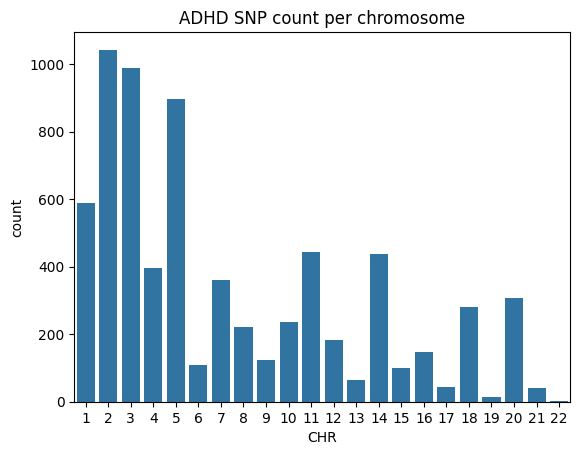

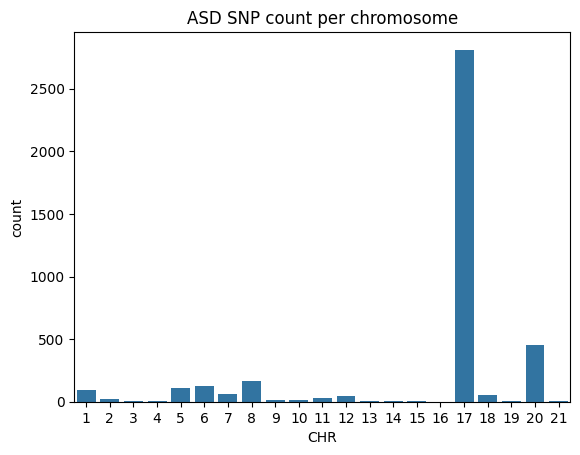

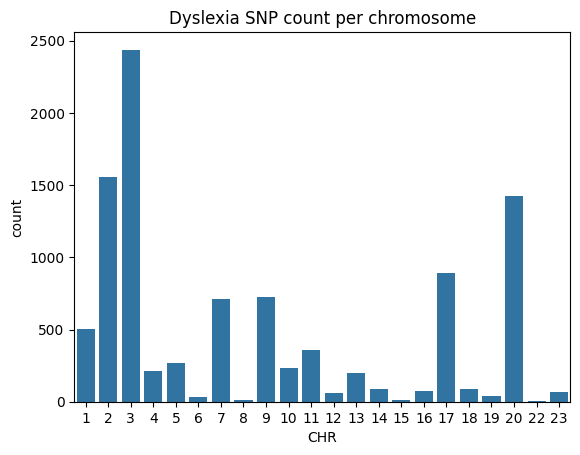

In [29]:
# SNP Count per Chromosome

sns.countplot(data=ADHD_df, x="CHR")
plt.title("ADHD SNP count per chromosome")
plt.show()

sns.countplot(data=ASD_df, x="CHR")
plt.title("ASD SNP count per chromosome")
plt.show()

sns.countplot(data=dys_df, x="CHR")
plt.title("Dyslexia SNP count per chromosome")
plt.show()

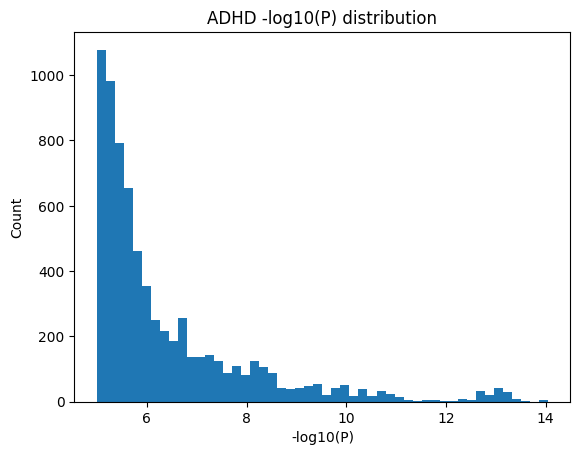

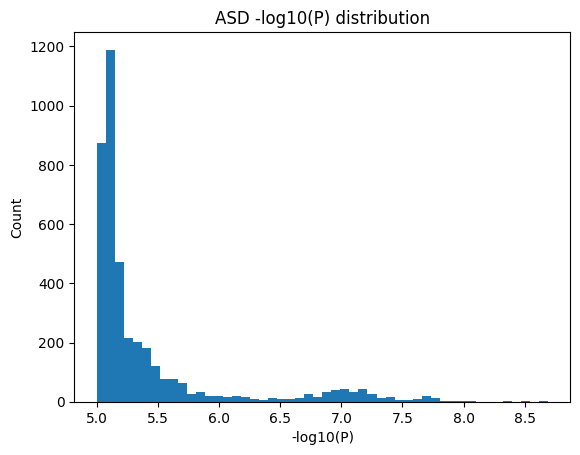

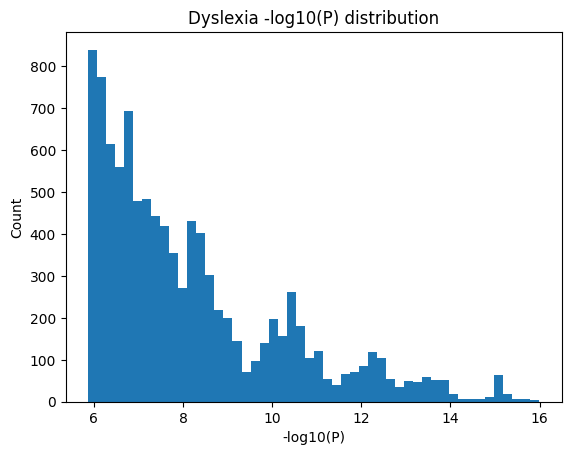

In [30]:
# P-value Distribution

plt.hist(-np.log10(ADHD_df['P']), bins=50)
plt.title("ADHD -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

plt.hist(-np.log10(ASD_df['P']), bins=50)
plt.title("ASD -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

plt.hist(-np.log10(dys_df['P']), bins=50)
plt.title("Dyslexia -log10(P) distribution")
plt.xlabel("-log10(P)")
plt.ylabel("Count")
plt.show()

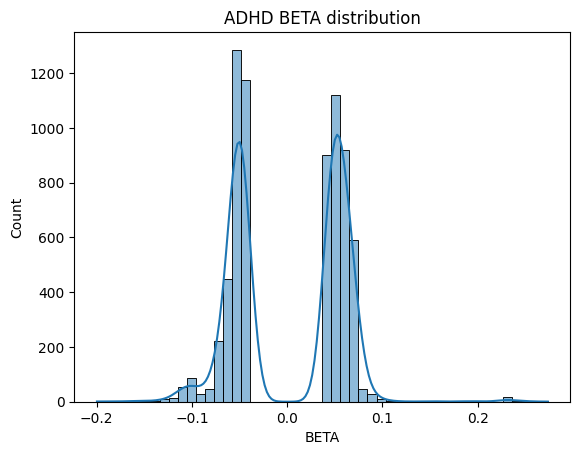

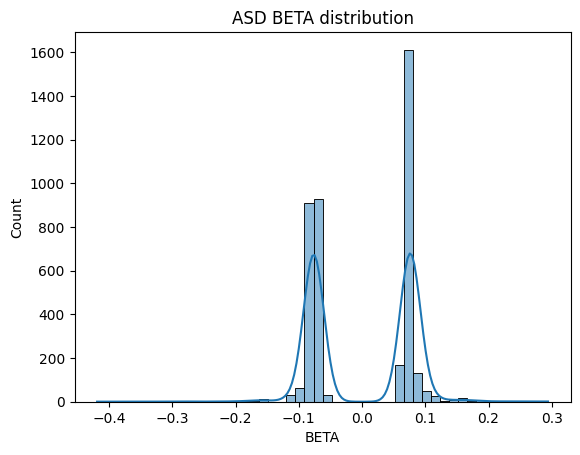

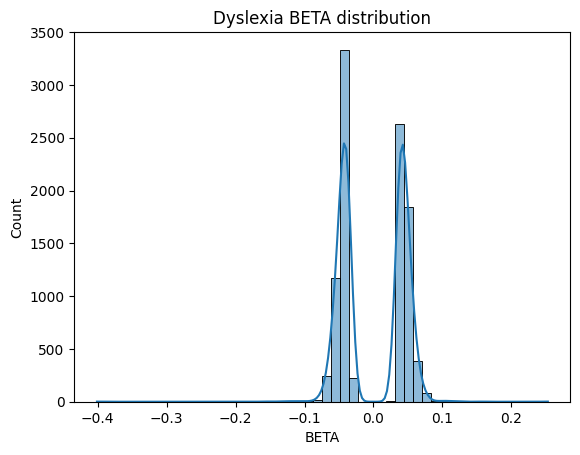

In [31]:
# Beta Distribution
sns.histplot(ADHD_df['BETA'], bins=50, kde=True)
plt.title("ADHD BETA distribution")
plt.show()

sns.histplot(ASD_df['BETA'], bins=50, kde=True)
plt.title("ASD BETA distribution")
plt.show()

sns.histplot(dys_df['BETA'], bins=50, kde=True)
plt.title("Dyslexia BETA distribution")
plt.show()

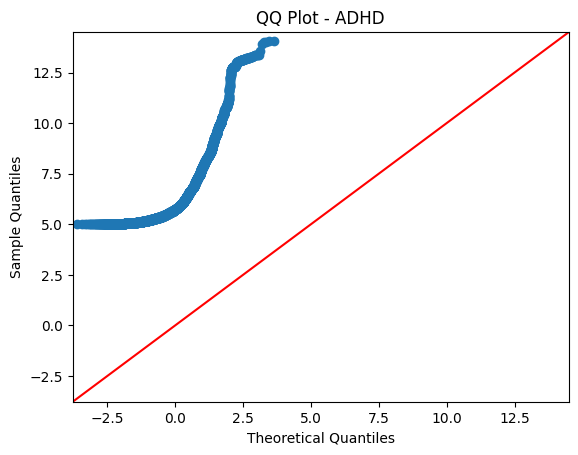

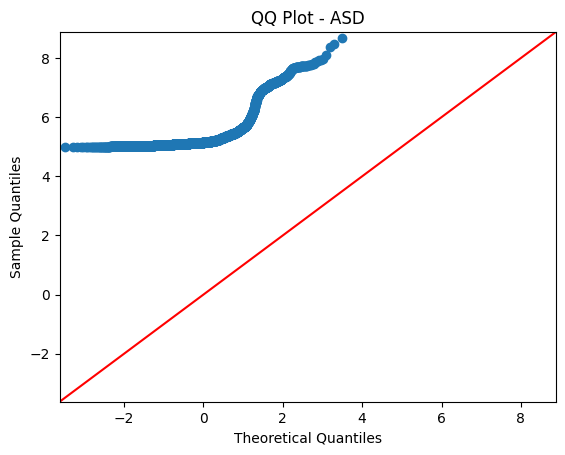

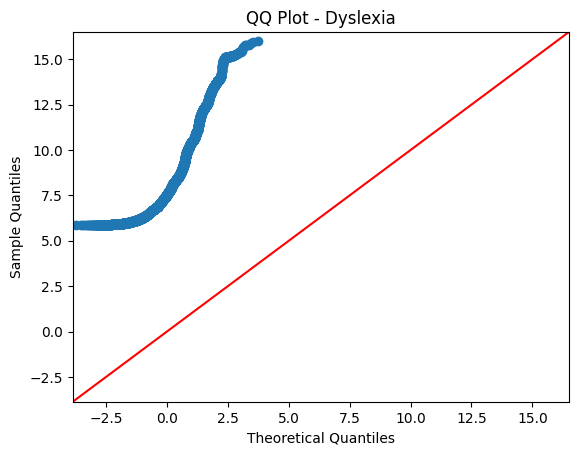

In [32]:
#QQ-Plot (Compare expected vs observed p-values)

from statsmodels.graphics.gofplots import qqplot


qqplot(-np.log10(ADHD_df["P"]), line="45")
plt.title("QQ Plot - ADHD")
plt.show()

qqplot(-np.log10(ASD_df["P"]), line="45")
plt.title("QQ Plot - ASD")
plt.show()

qqplot(-np.log10(dys_df["P"]), line="45")
plt.title("QQ Plot - Dyslexia")
plt.show()

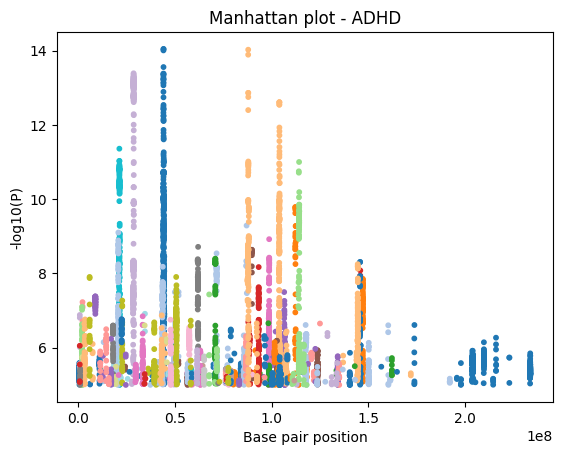

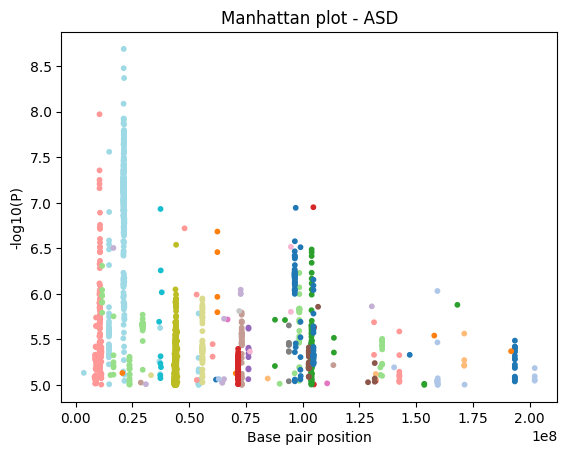

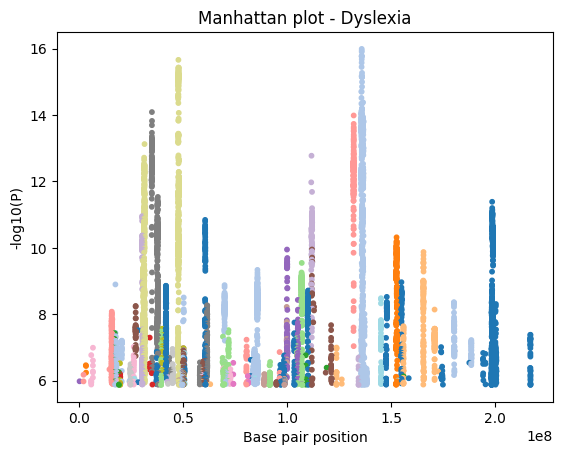

In [33]:
#Manhattan Plot (For a visual overview of SNP significance across the genome)

ADHD_df['-log10P'] = -np.log10(ADHD_df['P'])
plt.scatter(ADHD_df['BP'], ADHD_df['-log10P'], c=ADHD_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - ADHD")
plt.show()

ASD_df['-log10P'] = -np.log10(ASD_df['P'])
plt.scatter(ASD_df['BP'], ASD_df['-log10P'], c=ASD_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - ASD")
plt.show()

dys_df['-log10P'] = -np.log10(dys_df['P'])
plt.scatter(dys_df['BP'], dys_df['-log10P'], c=dys_df['CHR'], cmap='tab20', s=10)
plt.xlabel("Base pair position")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot - Dyslexia")
plt.show()

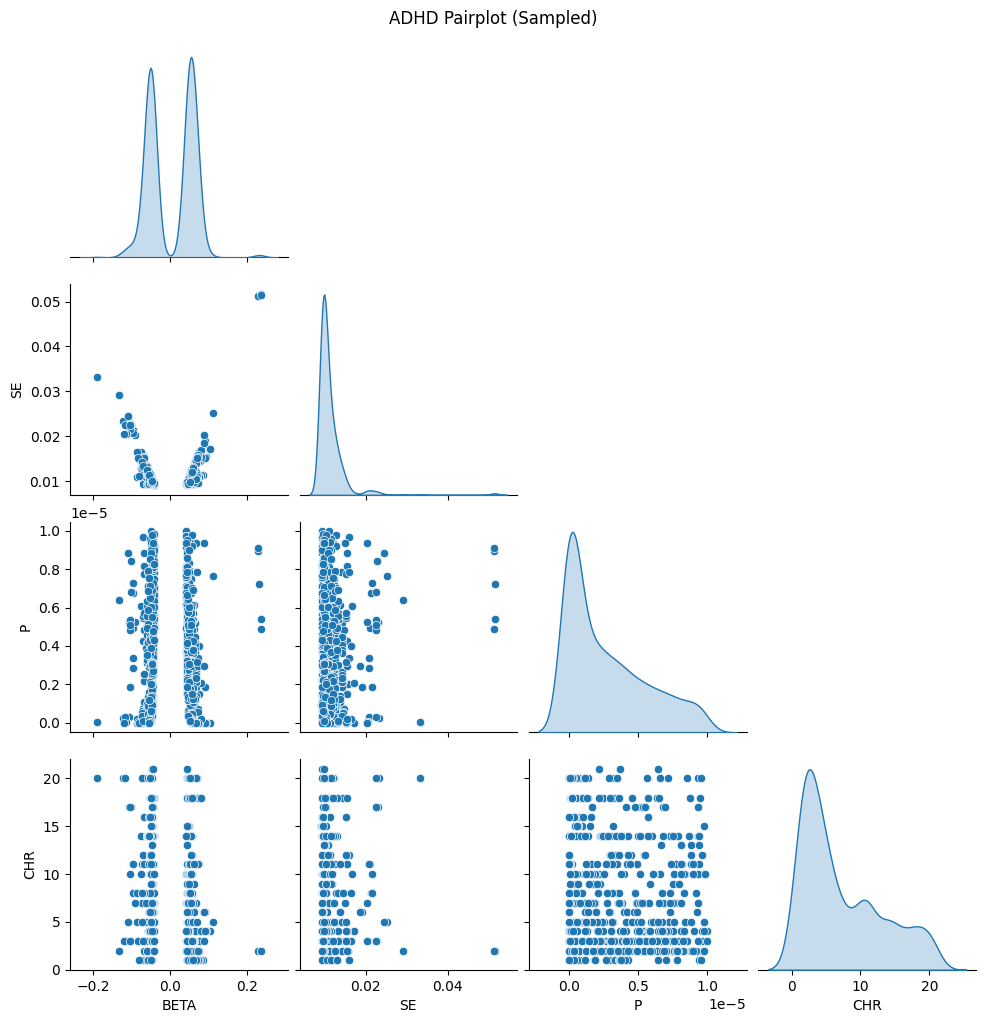

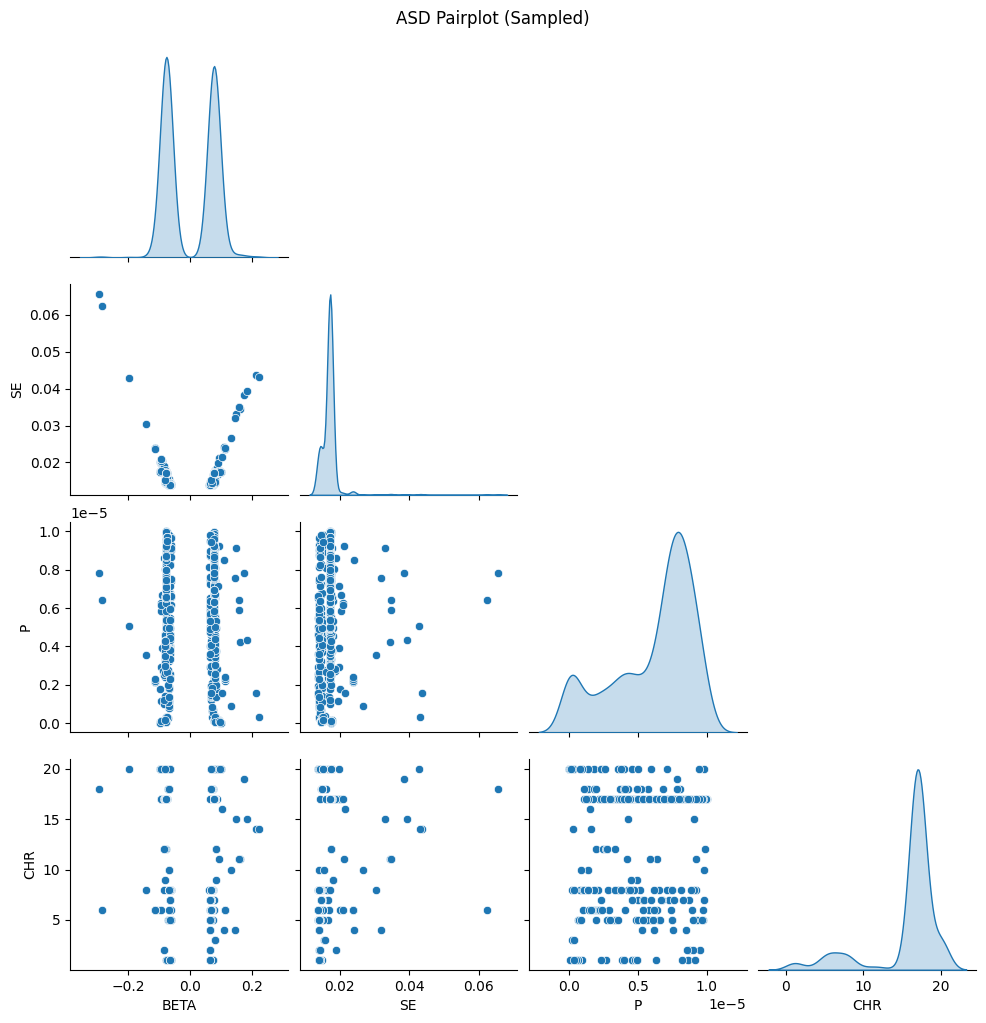

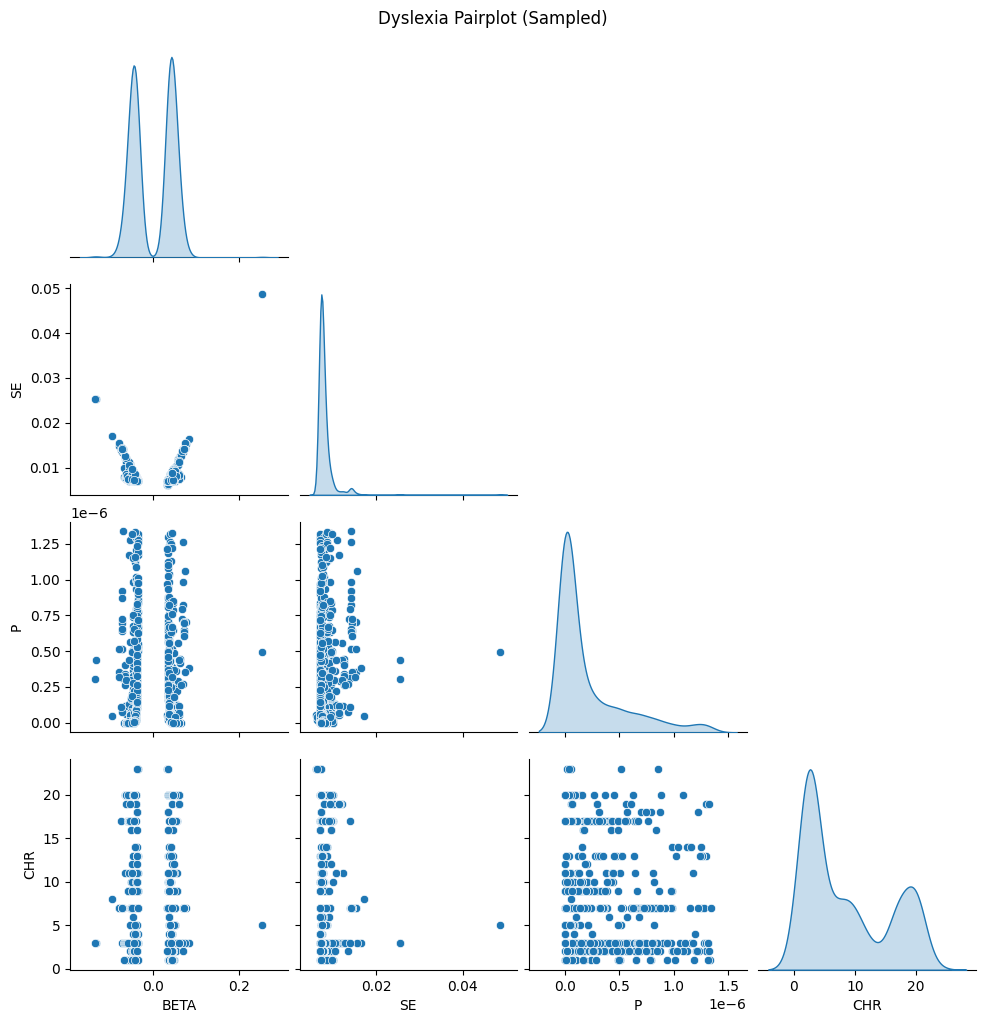

In [34]:
# Pair Plots

adhd_sample = ADHD_df.sample(n=1000, random_state=42)

sns.pairplot(
    adhd_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("ADHD Pairplot (Sampled)", y=1.02)
plt.show()

asd_sample = ASD_df.sample(n=1000, random_state=42)

sns.pairplot(
    asd_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("ASD Pairplot (Sampled)", y=1.02)
plt.show()

dys_sample = dys_df.sample(n=1000, random_state=42)

sns.pairplot(
    dys_sample[['BETA', 'SE', 'P', 'CHR']],
    diag_kind='kde',
    corner=True
)

plt.suptitle("Dyslexia Pairplot (Sampled)", y=1.02)
plt.show()

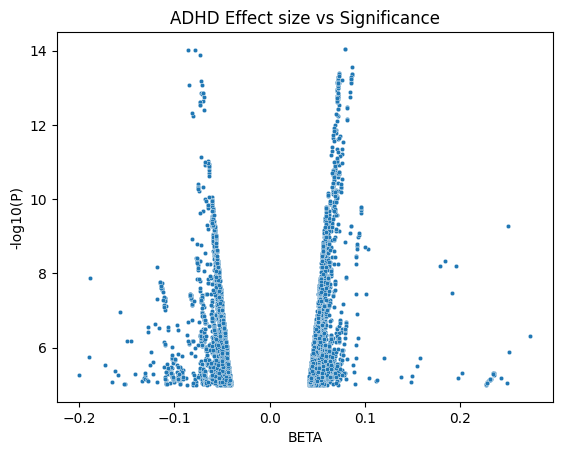

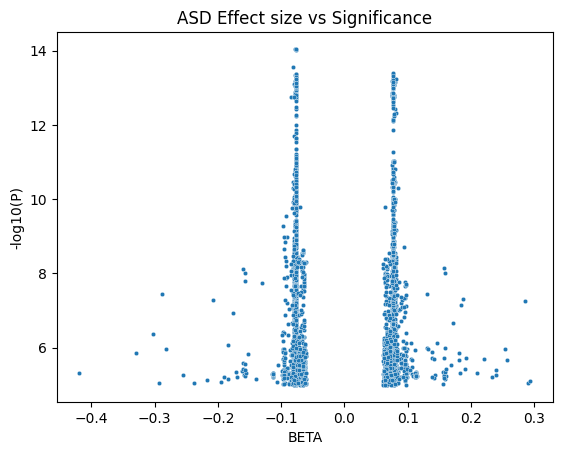

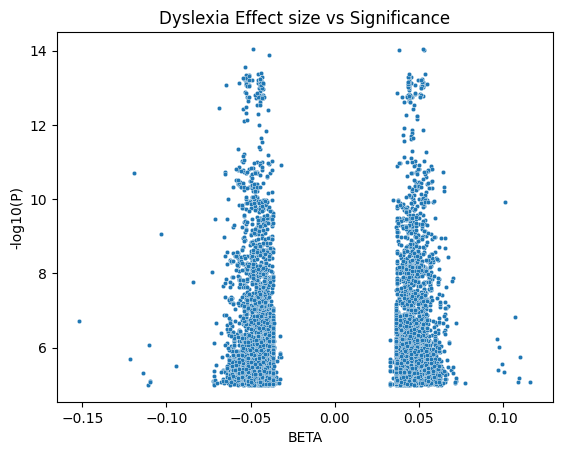

In [35]:
# Effect size vs significance

sns.scatterplot(
    x=ADHD_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("ADHD Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()

sns.scatterplot(
    x=ASD_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("ASD Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()

sns.scatterplot(
    x=dys_df['BETA'],
    y=-np.log10(ADHD_df['P']),
    s=10
)
plt.title("Dyslexia Effect size vs Significance")
plt.xlabel("BETA")
plt.ylabel("-log10(P)")
plt.show()


### Clean GWAS files

In [19]:
# Keep only required columns
cols_to_keep = ['SNP', 'CHR', 'BP', 'P']

ADHD_df = ADHD_df[cols_to_keep]
ASD_df = ASD_df[cols_to_keep]
dys_df = dys_df[cols_to_keep]

# Remove missing
ADHD_df = ADHD_df.dropna()
ASD_df = ASD_df.dropna()
dys_df = dys_df.dropna()

# Convert P to numeric
ADHD_df['P'] = pd.to_numeric(ADHD_df['P'], errors='coerce')
ASD_df['P'] = pd.to_numeric(ASD_df['P'], errors='coerce')
dys_df['P'] = pd.to_numeric(dys_df['P'], errors='coerce')

ADHD_df = ADHD_df.dropna(subset=['P'])
ASD_df = ASD_df.dropna(subset=['P'])
dys_df = dys_df.dropna(subset=['P'])

print("ADHD Total SNPs:", len(ADHD_df))
print("ASD Total SNPs:", len(ASD_df))
print("Dyslexia Total SNPs:", len(dys_df))

ADHD Total SNPs: 6774224
ASD Total SNPs: 9112386
Dyslexia Total SNPs: 10000


In [20]:
# Select significant SNPs
threshold = 1e-5
sig_ADHD = ADHD_df[ADHD_df['P'] < threshold]
sig_ASD = ASD_df[ASD_df['P'] < threshold]
sig_dys = dys_df[dys_df['P'] < threshold]

print("Significant ADHD SNPs:", len(sig_ADHD))
print("Significant ASD SNPs:", len(sig_ASD))
print("Significant Dyslexia SNPs:", len(sig_dys))

Significant ADHD SNPs: 7033
Significant ASD SNPs: 4027
Significant Dyslexia SNPs: 10000


In [21]:
# Save rsIDs
sig_ADHD['SNP'].to_csv("significant_ADHD_snps.txt", index=False, header=False)
sig_ADHD.to_csv("significant_ADHD_snps_full.tsv", sep="\t", index=False)

sig_ASD['SNP'].to_csv("significant_ASD_snps.txt", index=False, header=False)
sig_ASD.to_csv("significant_ASD_snps_full.tsv", sep="\t", index=False)

sig_dys['SNP'].to_csv("significant_dys_snps.txt", index=False, header=False)
sig_dys.to_csv("significant_dys_snps_full.tsv", sep="\t", index=False)

### SNP → Gene Mapping

In [22]:
ADHD_snps = pd.read_csv("significant_ADHD_snps.txt", header=None)[0].tolist()
ASD_snps = pd.read_csv("significant_ASD_snps.txt", header=None)[0].tolist()
dys_snps = pd.read_csv("significant_dys_snps.txt", header=None)[0].tolist()

In [23]:
server = "https://rest.ensembl.org"
variant_ext = "/variation/human/{}?content-type=application/json"
overlap_ext = "/overlap/region/human/{}?feature=gene"

headers = {"Content-Type": "application/json"}

In [24]:
def gene_mapping(snps, disorder_name, output_file):

    snp_gene_map = []

    for snp in tqdm(snps, desc=f"Mapping {disorder_name} SNPs"):

        try:
            # --- Step 1: Get SNP location ---
            r = requests.get(server + variant_ext.format(snp), headers=headers)

            if not r.ok:
                continue

            decoded = r.json()

            if 'mappings' not in decoded or len(decoded['mappings']) == 0:
                continue

            # take first genomic mapping
            chr_loc = decoded['mappings'][0].get('location', None)

            if chr_loc is None:
                continue

            # --- Step 2: Find overlapping genes ---
            r2 = requests.get(server + overlap_ext.format(chr_loc), headers=headers)

            if not r2.ok:
                continue

            genes = r2.json()

            if len(genes) == 0:
                continue

            for g in genes:
                gene_name = g.get('external_name', None)

                if gene_name:
                    snp_gene_map.append([snp, gene_name, disorder_name])

            # IMPORTANT: avoid API ban
            time.sleep(0.35)

        except Exception as e:
            continue

    # Save once after loop
    df_map = pd.DataFrame(snp_gene_map, columns=["SNP", "GENE", "DISORDER"])
    df_map.to_csv(output_file, sep="\t", index=False)

    print(f"{disorder_name} mapped genes:", len(df_map))

In [25]:
gene_mapping(ADHD_snps, "ADHD", "ADHD_snp_gene_mapping.tsv")
gene_mapping(ASD_snps, "ASD", "ASD_snp_gene_mapping.tsv")
gene_mapping(dys_snps, "dyslexia", "dys_snp_gene_mapping.tsv")

Mapping ADHD SNPs:   2%|▏         | 144/7033 [04:57<3:57:28,  2.07s/it]


KeyboardInterrupt: 

### Create Gene Scores

In [3]:
ADHD_gwas = pd.read_csv("significant_ADHD_snps_full.tsv", sep="\t")
ADHD_mapping = pd.read_csv("ADHD_snp_gene_mapping.tsv", sep="\t")

# merge
ADHD_merged = ADHD_gwas.merge(ADHD_mapping, on="SNP")

# compute gene score
ADHD_gene_scores = ADHD_merged.groupby('GENE')['P'].min().reset_index()

# -log10 transform
ADHD_gene_scores['GENE_SCORE'] = -np.log10(ADHD_gene_scores['P'])

ADHD_gene_scores = ADHD_gene_scores.sort_values(by='GENE_SCORE', ascending=False)

ADHD_gene_scores.to_csv("ADHD_gene_scores.tsv", sep="\t", index=False)

print(ADHD_gene_scores.head())

            GENE             P  GENE_SCORE
202        PTPRF  9.033000e-15   14.044168
165     MIR9-2HG  9.477000e-15   14.023329
107        KDM4A  2.295000e-12   11.639217
108    KDM4A-AS1  2.295000e-12   11.639217
241  ST3GAL3-AS1  5.469000e-12   11.262092


In [4]:
ASD_gwas = pd.read_csv("significant_ASD_snps_full.tsv", sep="\t")
ASD_mapping = pd.read_csv("ASD_snp_gene_mapping.tsv", sep="\t")

# merge
ASD_merged = ASD_gwas.merge(ASD_mapping, on="SNP")

# compute gene score
ASD_gene_scores = ASD_merged.groupby('GENE')['P'].min().reset_index()

# -log10 transform
ASD_gene_scores['GENE_SCORE'] = -np.log10(ASD_gene_scores['P'])

ASD_gene_scores = ASD_gene_scores.sort_values(by='GENE_SCORE', ascending=False)

ASD_gene_scores.to_csv("ASD_gene_scores.tsv", sep="\t", index=False)

print(ASD_gene_scores.head())

       GENE             P  GENE_SCORE
23      KIZ  8.160000e-09    8.088310
24  KIZ-AS1  8.160000e-09    8.088310
71     XRN2  1.589000e-08    7.798876
33  MACROD2  2.752000e-08    7.560352
61     SOX7  4.404000e-08    7.356153


In [5]:
dys_gwas = pd.read_csv("significant_dys_snps_full.tsv", sep="\t")
dys_mapping = pd.read_csv("dys_snp_gene_mapping.tsv", sep="\t")

# merge
dys_merged = dys_gwas.merge(dys_mapping, on="SNP")

# compute gene score
dys_gene_scores = dys_merged.groupby('GENE')['P'].min().reset_index()

# -log10 transform
dys_gene_scores['GENE_SCORE'] = -np.log10(dys_gene_scores['P'])

dys_gene_scores = dys_gene_scores.sort_values(by='GENE_SCORE', ascending=False)

dys_gene_scores.to_csv("dys_gene_scores.tsv", sep="\t", index=False)

print(dys_gene_scores.head())

         GENE             P  GENE_SCORE
178   PPP2R3A  1.028853e-16   15.987647
48   CSE1L-DT  2.197010e-16   15.658168
8     ARFGEF2  2.197010e-16   15.658168
47      CSE1L  3.754577e-16   15.425439
223     STAU1  5.574956e-16   15.253759


### Gene → Pathway Enrichment

In [6]:
# load official human gene symbols
hgnc = pd.read_csv("hgnc_complete_set.txt", sep="\t", low_memory=False)

# keep only approved protein-coding genes
hgnc = hgnc[hgnc['locus_group'] == 'protein-coding gene']

valid_genes = set(hgnc['symbol'].str.upper())

print("Number of valid human protein-coding genes:", len(valid_genes))

Number of valid human protein-coding genes: 19296


In [7]:
ADHD_genes = pd.read_csv("ADHD_gene_scores.tsv", sep="\t")

ADHD_genes['GENE'] = ADHD_genes['GENE'].str.upper()

ADHD_clean = ADHD_genes[ADHD_genes['GENE'].isin(valid_genes)]

ADHD_top_genes = ADHD_clean[ADHD_clean['GENE_SCORE'] > 3]['GENE'].dropna().unique().tolist()

print("Before cleaning:", len(ADHD_genes))
print("After HGNC filtering:", len(ADHD_clean))
print("Usable genes:", len(ADHD_top_genes))

ADHD_enr = gp.enrichr(
    gene_list=ADHD_top_genes,
    organism='Human',
    gene_sets=['GO_Biological_Process_2023','KEGG_2021_Human','Reactome_2022'],
    outdir='ADHD_enrichr_results'
)

# enrichment table
results = ADHD_enr.results
results


Before cleaning: 279
After HGNC filtering: 196
Usable genes: 196


2026-02-25 15:39:18,313 [ERROR] Gene set KEGG_2021_Human generated an exception: [Errno 2] No such file or directory: 'ADHD_enrichr_results/KEGG_2021_Human.Human.enrichr.reports.txt'
2026-02-25 15:39:18,330 [ERROR] Gene set GO_Biological_Process_2023 generated an exception: [Errno 2] No such file or directory: 'ADHD_enrichr_results/GO_Biological_Process_2023.Human.enrichr.reports.txt'
2026-02-25 15:39:18,376 [ERROR] Gene set Reactome_2022 generated an exception: [Errno 2] No such file or directory: 'ADHD_enrichr_results/Reactome_2022.Human.enrichr.reports.txt'


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Myogenesis R-HSA-525793,4/29,0.000175,0.108713,0,0,16.482500,142.553218,MEF2C;TCF12;CTNNB1;CTNNA2
1,KEGG_2021_Human,Arachidonate Production From DAG R-HSA-426048,2/5,0.000937,0.290507,0,0,68.044674,474.455043,DAGLA;MGLL
2,KEGG_2021_Human,Acyl Chain Remodeling Of DAG And TAG R-HSA-148...,2/7,0.001943,0.291225,0,0,40.822680,254.884515,MGLL;PNPLA2
3,KEGG_2021_Human,SHC-related Events Triggered By IGF1R R-HSA-24...,2/8,0.002574,0.291225,0,0,34.017182,202.826699,IGF1;IGF1R
4,KEGG_2021_Human,Adherens Junctions Interactions R-HSA-418990,3/29,0.002807,0.291225,0,0,11.824233,69.474396,CADM2;CTNNB1;CDH8
...,...,...,...,...,...,...,...,...,...,...
1855,Reactome_2022,PIP3 Activates AKT Signaling R-HSA-1257604,1/268,0.929855,0.935893,0,0,0.375242,0.027290,ERBB3
1856,Reactome_2022,Membrane Trafficking R-HSA-199991,3/599,0.935705,0.940254,0,0,0.500956,0.033291,CAPZA2;HPS1;ANK2
1857,Reactome_2022,Sensory Perception R-HSA-9709957,3/616,0.943198,0.946250,0,0,0.486632,0.028458,CAPZA2;GNAT1;BSN
1858,Reactome_2022,Vesicle-mediated Transport R-HSA-5653656,3/637,0.951341,0.952877,0,0,0.469999,0.023445,CAPZA2;HPS1;ANK2


In [8]:
ASD_genes = pd.read_csv("ASD_gene_scores.tsv", sep="\t")

ASD_genes['GENE'] = ASD_genes['GENE'].str.upper()

ASD_clean = ASD_genes[ASD_genes['GENE'].isin(valid_genes)]

ASD_top_genes = ASD_clean[ASD_clean['GENE_SCORE'] > 3]['GENE'].dropna().unique().tolist()

print("Before cleaning:", len(ASD_genes))
print("After HGNC filtering:", len(ASD_clean))
print("Usable genes:", len(ASD_top_genes))

ASD_enr = gp.enrichr(
    gene_list=ASD_top_genes,
    organism='Human',
    gene_sets=['GO_Biological_Process_2023','KEGG_2021_Human','Reactome_2022'],
    outdir='ASD_enrichr_results'
)

# enrichment table
results = ASD_enr.results
results


Before cleaning: 78
After HGNC filtering: 56
Usable genes: 56


2026-02-25 15:39:24,602 [ERROR] Gene set KEGG_2021_Human generated an exception: [Errno 2] No such file or directory: 'ASD_enrichr_results/KEGG_2021_Human.Human.enrichr.reports.txt'
2026-02-25 15:39:24,643 [ERROR] Gene set Reactome_2022 generated an exception: [Errno 2] No such file or directory: 'ASD_enrichr_results/Reactome_2022.Human.enrichr.reports.txt'
2026-02-25 15:39:24,697 [ERROR] Gene set GO_Biological_Process_2023 generated an exception: [Errno 2] No such file or directory: 'ASD_enrichr_results/GO_Biological_Process_2023.Human.enrichr.reports.txt'


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,RUNX1 Regulates Transcription Of Genes Involve...,2/6,0.000115,0.027292,0,0,184.629630,1675.224892,BLK;RUNX1
1,KEGG_2021_Human,Caspase-mediated Cleavage Of Cytoskeletal Prot...,2/12,0.000499,0.059398,0,0,73.829630,561.298343,CASP8;MAPT
2,KEGG_2021_Human,Apoptotic Cleavage Of Cellular Proteins R-HSA-...,2/38,0.005074,0.182835,0,0,20.481481,108.214878,CASP8;MAPT
3,KEGG_2021_Human,Binding And Uptake Of Ligands By Scavenger Rec...,2/41,0.005887,0.182835,0,0,18.903134,97.066961,COL4A1;HPR
4,KEGG_2021_Human,Gene Expression (Transcription) R-HSA-74160,10/1449,0.006415,0.182835,0,0,2.795571,14.115102,KMT2E;BLK;NFIA;NEDD4L;ZNF568;JARID2;PLXNA4;RUN...
...,...,...,...,...,...,...,...,...,...,...
709,GO_Biological_Process_2023,Hemostasis R-HSA-109582,1/576,0.805780,0.819554,0,0,0.612458,0.132257,SERPINA1
710,GO_Biological_Process_2023,Sensory Perception R-HSA-9709957,1/616,0.826983,0.835499,0,0,0.571441,0.108557,KCNN2
711,GO_Biological_Process_2023,GPCR Downstream Signaling R-HSA-388396,1/619,0.828478,0.835499,0,0,0.568579,0.106987,CRHR1
712,GO_Biological_Process_2023,Cell Cycle R-HSA-1640170,1/654,0.845012,0.848578,0,0,0.537129,0.090455,KANSL1


In [9]:
dys_genes = pd.read_csv("dys_gene_scores.tsv", sep="\t")

dys_genes['GENE'] = dys_genes['GENE'].str.upper()

dys_clean = dys_genes[dys_genes['GENE'].isin(valid_genes)]

dys_top_genes = dys_clean[dys_clean['GENE_SCORE'] > 3]['GENE'].dropna().unique().tolist()

print("Before cleaning:", len(dys_genes))
print("After HGNC filtering:", len(dys_clean))
print("Usable genes:", len(dys_top_genes))

dys_enr = gp.enrichr(
    gene_list=dys_top_genes,
    organism='Human',
    gene_sets=['GO_Biological_Process_2023','KEGG_2021_Human','Reactome_2022'],
    outdir='dys_enrichr_results'
)

# enrichment table
results = dys_enr.results
results


Before cleaning: 247
After HGNC filtering: 194
Usable genes: 194


2026-02-25 15:39:31,834 [ERROR] Gene set GO_Biological_Process_2023 generated an exception: [Errno 2] No such file or directory: 'dys_enrichr_results/GO_Biological_Process_2023.Human.enrichr.reports.txt'
2026-02-25 15:39:31,862 [ERROR] Gene set KEGG_2021_Human generated an exception: [Errno 2] No such file or directory: 'dys_enrichr_results/KEGG_2021_Human.Human.enrichr.reports.txt'
2026-02-25 15:39:31,868 [ERROR] Gene set Reactome_2022 generated an exception: [Errno 2] No such file or directory: 'dys_enrichr_results/Reactome_2022.Human.enrichr.reports.txt'


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2023,DARPP-32 Events R-HSA-180024,4/24,0.000078,0.055069,0,0,20.827368,196.912779,PPP2R1B;PRKAR2B;PDE4D;PPP1R1B
1,GO_Biological_Process_2023,TFAP2A Acts As A Transcriptional Repressor Dur...,2/5,0.000918,0.322757,0,0,68.760417,480.846011,NPM1;HSPD1
2,GO_Biological_Process_2023,Opioid Signaling R-HSA-111885,5/88,0.001666,0.348367,0,0,6.286416,40.215138,PPP2R1B;PRKAR2B;PDE4D;GNAQ;PPP1R1B
3,GO_Biological_Process_2023,Cholesterol Biosynthesis R-HSA-191273,3/26,0.001982,0.348367,0,0,13.509902,84.079703,PMVK;CYP51A1;SH3D19
4,GO_Biological_Process_2023,Netrin Mediated Repulsion Signals R-HSA-418886,2/8,0.002522,0.354615,0,0,34.375000,205.653351,PTPN11;UNC5D
...,...,...,...,...,...,...,...,...,...,...
2104,Reactome_2022,Translation R-HSA-72766,1/281,0.936609,0.941968,0,0,0.361325,0.023663,MARS2
2105,Reactome_2022,Sensory Perception R-HSA-9709957,3/616,0.940546,0.944577,0,0,0.491779,0.030144,NMT1;CABP1;GPC6
2106,Reactome_2022,Cellular Responses To Stress R-HSA-2262752,3/722,0.972951,0.975727,0,0,0.416962,0.011434,PSMA5;CREBRF;CRYAB
2107,Reactome_2022,Cellular Responses To Stimuli R-HSA-8953897,3/736,0.975696,0.977086,0,0,0.408698,0.010056,PSMA5;CREBRF;CRYAB


### Convert to ML Features

In [10]:
import pandas as pd
import numpy as np

# load enrichment outputs
adhd = ADHD_enr.results
asd  = ASD_enr.results
dys  = dys_enr.results

# build master pathway dictionary
ALL_PATHWAYS = sorted(set(adhd['Term']) | set(asd['Term']) | set(dys['Term']))

# adhd = adhd[adhd['Adjusted P-value'] < 0.05]
# asd  = asd[asd['Adjusted P-value'] < 0.05]
# dys  = dys[dys['Adjusted P-value'] < 0.05]

def make_vector(df, pathway_list):
    vec = pd.Series(0.0, index=pathway_list)

    for _, row in df.iterrows():
        pathway = row['Term']
        score = -np.log10(row['Adjusted P-value'])

        if pathway in vec.index:
            vec[pathway] = score

    # normalization
    vec = (vec - vec.mean()) / (vec.std() + 1e-8)
    return vec

ADHD_vec = make_vector(adhd, ALL_PATHWAYS)
ASD_vec  = make_vector(asd, ALL_PATHWAYS)
DYS_vec  = make_vector(dys, ALL_PATHWAYS)

genetic_features = pd.DataFrame([
    ADHD_vec,
    ASD_vec,
    DYS_vec
], index=['ADHD','ASD','Dyslexia'])

genetic_features.to_csv("genetic_feature_matrix.csv")

print("Genetic feature shape:", genetic_features.shape)


Genetic feature shape: (3, 1028)


In this notebook, we performed genetic data preprocessing for our cross-disorder study involving ADHD, Autism Spectrum Disorder (ASD), and Dyslexia. 

#### The main steps included:

- Selection of significant SNPs and genes
    - SNPs associated with each disorder were mapped to their corresponding genes.
    - Genes were filtered using a gene score threshold and verified against the HGNC human protein-coding gene list.

- Gene Set Enrichment Analysis (GSEA)
    - Top genes for each disorder were analyzed using Enrichr to identify enriched biological pathways across GO Biological Processes, KEGG, and Reactome databases.
    - Adjusted p-value filtering (< 0.05) ensured that only statistically significant pathways were considered.

- Construction of disorder-specific pathway vectors
    - Each disorder was represented as a vector of pathway scores, where the score reflects the pathway’s significance (-log10 Adjusted P-value).
    - Vectors were z-score normalized to make them comparable across disorders.

- Final genetic feature matrix
    - The resulting genetic feature matrix (genetic_feature_matrix.csv) has disorders as rows and enriched pathways as columns, capturing the functional genomic profile of ADHD, ASD, and Dyslexia.
    - Current shape: (3 disorders × 974 pathways).
    - Sparse pathways (no significant enrichment) have values of 0.

#### State of the Data

- Each row corresponds to a disorder (ADHD, ASD, Dyslexia).

- Each column corresponds to a pathway enriched in at least one disorder.

- Values represent standardized pathway significance scores (-log10 Adjusted P-value, z-scored).

- This dataset is now ready to serve as the genetic modality in a multi-modal machine learning framework.

#### Next Steps in the Project

- Integration with other modalities
      - Combine this genetic feature matrix with neuroimaging features (cortical thickness, subcortical volumes) and phenotypic/behavioral data (IQ, attention scores, reading measures).

- Multi-modal machine learning
    - Each modality will be processed through its own encoder (e.g., MLP or Transformer for genetics, CNN/MLP for imaging).
    - Outputs will be fused in a shared latent space to perform cross-disorder representation learning.